## Exploration des classes et du nombre d’images par classe

In [7]:
import os

base_dir = "data/images"

for label in os.listdir(base_dir):
    folder = os.path.join(base_dir, label)
    if os.path.isdir(folder):
        n_images = len(os.listdir(folder))
        print(f"{label}: {n_images} images")


battery: 944 images
biological: 997 images
cardboard: 1825 images
clothes: 5327 images
glass: 3061 images
metal: 1020 images
paper: 1680 images
plastic: 1984 images
shoes: 1977 images
trash: 947 images


## Affichage d’échantillons d’images

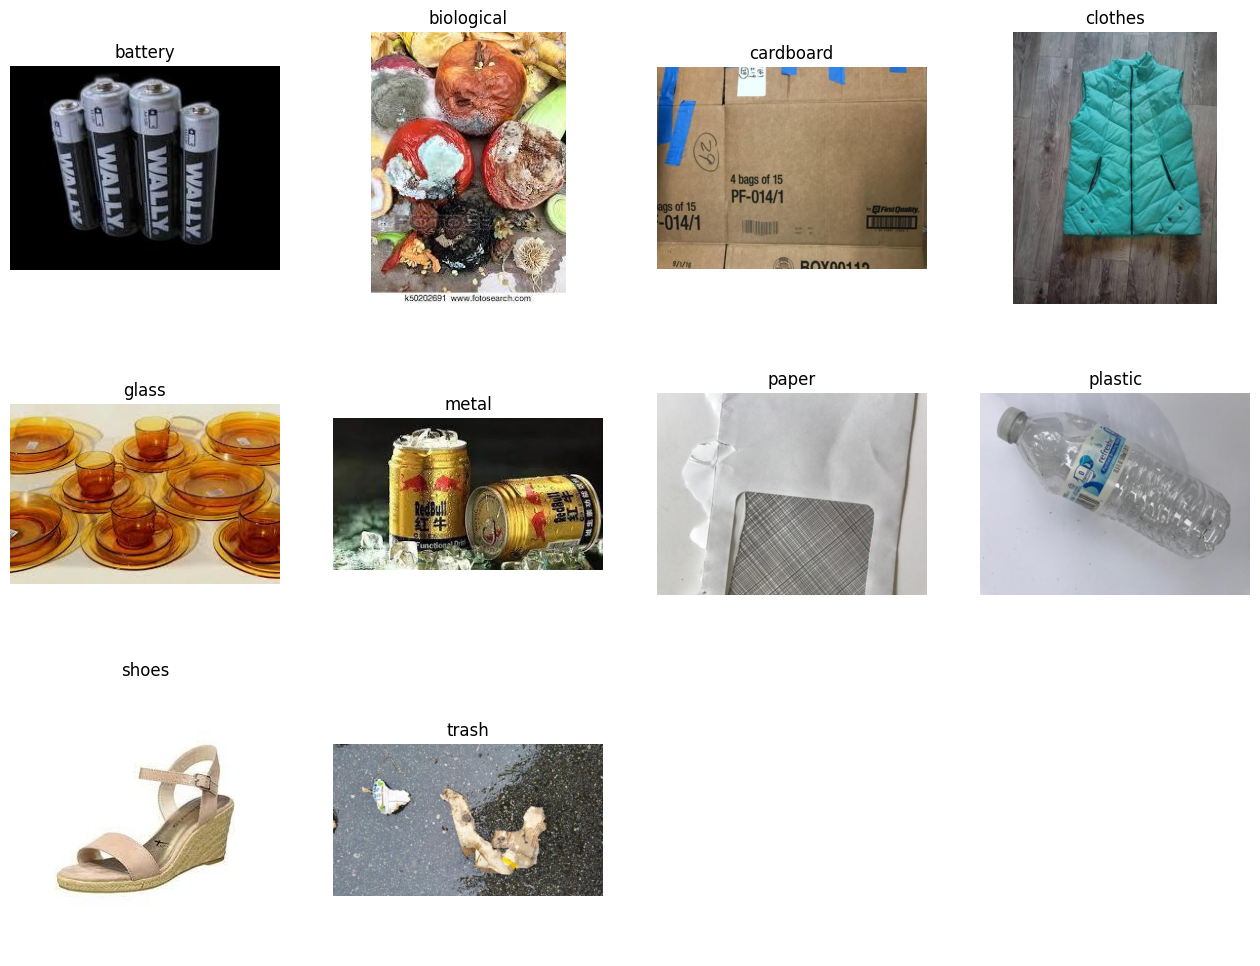

In [8]:
import math
import random
from PIL import Image
import matplotlib.pyplot as plt

if 'labels' not in globals():
    labels = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

n_labels = len(labels)
cols = 4
rows = math.ceil(n_labels / cols)

plt.figure(figsize=(4*cols, 4*rows))

for i, label in enumerate(labels):
    folder = os.path.join(base_dir, label)
    img_name = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_name)
    img = Image.open(img_path)
    
    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.show()


# Analyse des dimensions des images

In [9]:
from PIL import Image
import numpy as np

all_shapes = []

for label in labels:
    folder = os.path.join(base_dir, label)
    for img_file in os.listdir(folder):
        img_path = os.path.join(folder, img_file)
        img = Image.open(img_path)
        all_shapes.append(img.size)

all_shapes = np.array(all_shapes)
print("Min width:", all_shapes[:,0].min())
print("Max width:", all_shapes[:,0].max())
print("Min height:", all_shapes[:,1].min())
print("Max height:", all_shapes[:,1].max())


Min width: 51
Max width: 7786
Min height: 71
Max height: 6283


## Redimensionnement des images (Resize)

In [10]:
INPUT_SIZE = (224, 224)
resized_dir = "data/resized"

for label in labels:
    src_folder = os.path.join(base_dir, label)
    dst_folder = os.path.join(resized_dir, label)
    os.makedirs(dst_folder, exist_ok=True)

    for img_file in os.listdir(src_folder):
        img = Image.open(os.path.join(src_folder, img_file)).convert("RGB")
        img = img.resize(INPUT_SIZE, Image.LANCZOS)
        img.save(os.path.join(dst_folder, img_file))

print(f"{label}: {len(os.listdir(folder))} images")


trash: 947 images


## Séparation en train/validation

In [11]:
from sklearn.model_selection import train_test_split
import shutil

train_dir = "data/train"
val_dir = "data/val"

for label in labels:
    images = os.listdir(os.path.join(resized_dir, label))
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    for img in train_imgs:
        os.makedirs(os.path.join(train_dir, label), exist_ok=True)
        shutil.copy(os.path.join(resized_dir, label, img), os.path.join(train_dir, label, img))

    for img in val_imgs:
        os.makedirs(os.path.join(val_dir, label), exist_ok=True)
        shutil.copy(os.path.join(resized_dir, label, img), os.path.join(val_dir, label, img))


## Data Augmentation

In [12]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])


# Modeling & Evaluation

## Modeling Pipeline

### Imbalance

Weighted Loss

In [13]:
import torch
import torch.nn as nn
from torchvision import datasets

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create datasets
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=train_transforms)

labels = train_dataset.classes
print(f"Classes: {labels}")
print(f"Number of training images: {len(train_dataset)}")
print(f"Number of validation images: {len(val_dataset)}")

Using device: cpu
Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
Number of training images: 15806
Number of validation images: 3956


### Pretrained Model

In [14]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights="IMAGENET1K_V1")

num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)


In [15]:
# DataLoaders
from torch.utils.data import DataLoader

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Train batches: 494
Validation batches: 124


In [16]:
# Loss & Optimizer
from collections import Counter

# Calculate class weights for imbalanced data
class_counts = Counter(train_dataset.targets)
weights = [1.0 / class_counts[i] for i in range(len(class_counts))]
class_weights = torch.FloatTensor(weights).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

model = model.to(device)
print("Model moved to device")
print(f"Criterion: {criterion}")

Model moved to device
Criterion: CrossEntropyLoss()


In [17]:
# Training Loop
history = {
    'train_loss': [],
    'val_loss': [],
    'val_accuracy': []
}

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    batches = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        batches += 1
        
        if (batch_idx + 1) % 50 == 0:
            print(f"Batch [{batch_idx + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
    
    avg_loss = total_loss / batches
    return avg_loss

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    batches = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            batches += 1
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / batches
    accuracy = correct / total
    return avg_loss, accuracy

print("Training functions ready!")

Training functions ready!


In [ ]:
# Train the model
num_epochs = 5

for epoch in range(num_epochs):
    print(f"\n{'='*60}")
    print(f"Epoch [{epoch + 1}/{num_epochs}]")
    print(f"{'='*60}")
    
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    history['train_loss'].append(train_loss)
    
    # Validate
    val_loss, val_accuracy = validate(model, val_loader, criterion, device)
    history['val_loss'].append(val_loss)
    history['val_accuracy'].append(val_accuracy)
    
    print(f"\nEpoch Summary:")
    print(f"  Training Loss:     {train_loss:.4f}")
    print(f"  Validation Loss:   {val_loss:.4f}")
    print(f"  Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

print("\n" + "="*60)
print("Training Complete!")
print("="*60)


Epoch [1/5]
Batch [50/494], Loss: 1.4960
Batch [100/494], Loss: 1.4942
Batch [150/494], Loss: 0.8445
Batch [200/494], Loss: 0.6274
Batch [250/494], Loss: 0.8418
Batch [300/494], Loss: 0.7258
Batch [350/494], Loss: 1.1741
Batch [400/494], Loss: 0.7275
Batch [450/494], Loss: 0.6290

Epoch Summary:
  Training Loss:     1.0170
  Validation Loss:   1.0307
  Validation Accuracy: 0.6673 (66.73%)

Epoch [2/5]
Batch [50/494], Loss: 0.6094
Batch [100/494], Loss: 1.3529
Batch [150/494], Loss: 0.3928
Batch [200/494], Loss: 0.9027
Batch [250/494], Loss: 0.9151
Batch [300/494], Loss: 0.2562
Batch [350/494], Loss: 0.7838
Batch [400/494], Loss: 0.6090


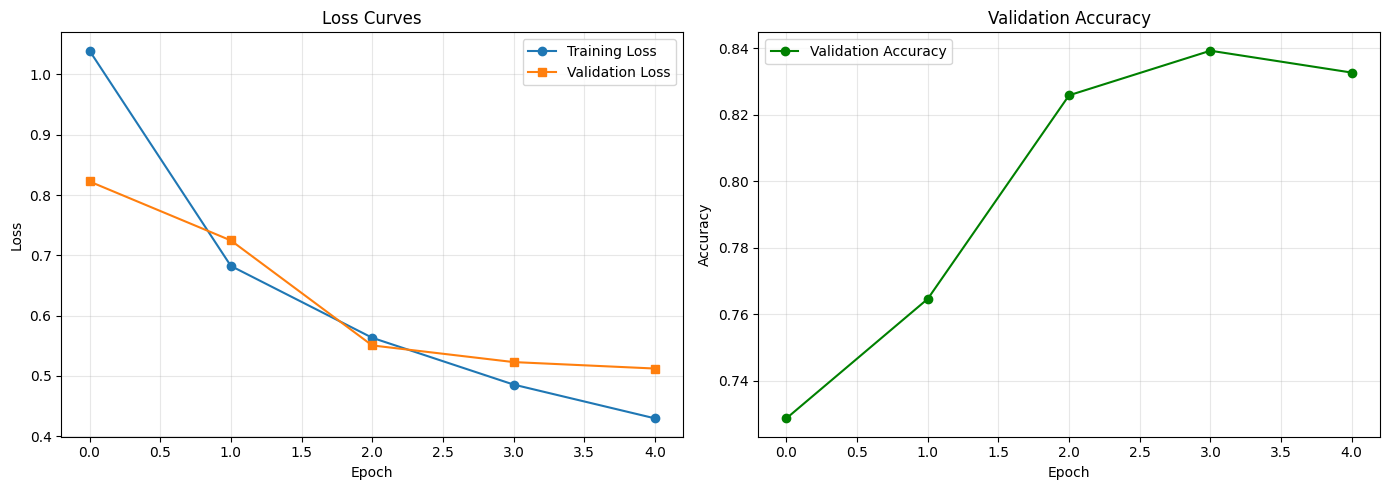


Final Metrics:
  Best Validation Accuracy: 0.8392
  Final Training Loss: 0.4297
  Final Validation Loss: 0.5123


In [ ]:
# Plot Training Curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(history['train_loss'], label='Training Loss', marker='o')
axes[0].plot(history['val_loss'], label='Validation Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history['val_accuracy'], label='Validation Accuracy', marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print(f"\nFinal Metrics:")
print(f"  Best Validation Accuracy: {max(history['val_accuracy']):.4f}")
print(f"  Final Training Loss: {history['train_loss'][-1]:.4f}")
print(f"  Final Validation Loss: {history['val_loss'][-1]:.4f}")

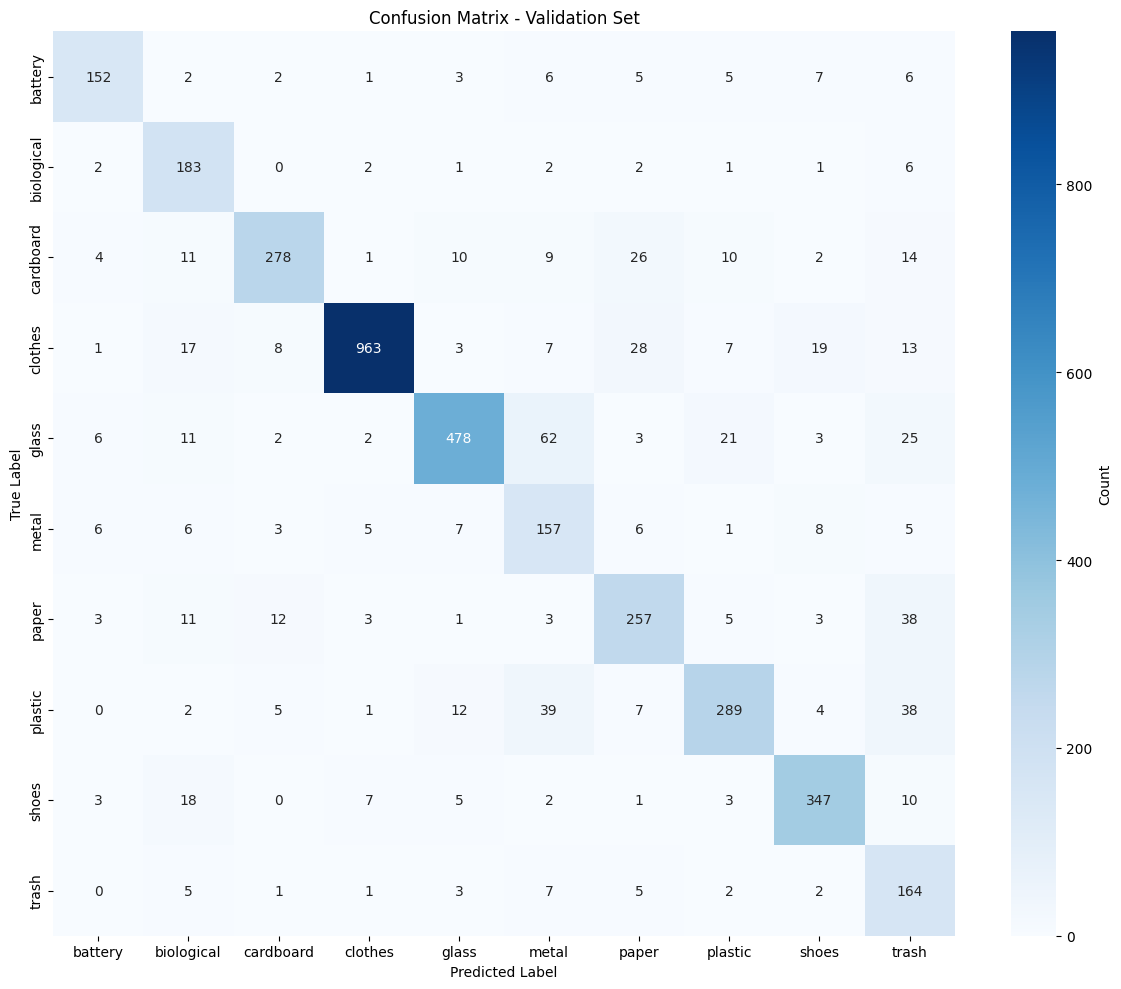


Classification Report:
              precision    recall  f1-score   support

     battery       0.86      0.80      0.83       189
  biological       0.69      0.92      0.79       200
   cardboard       0.89      0.76      0.82       365
     clothes       0.98      0.90      0.94      1066
       glass       0.91      0.78      0.84       613
       metal       0.53      0.77      0.63       204
       paper       0.76      0.76      0.76       336
     plastic       0.84      0.73      0.78       397
       shoes       0.88      0.88      0.88       396
       trash       0.51      0.86      0.64       190

    accuracy                           0.83      3956
   macro avg       0.79      0.82      0.79      3956
weighted avg       0.85      0.83      0.83      3956



In [ ]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Get predictions on validation set
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))


DETAILED CLASSIFICATION REPORT
     Class  Precision   Recall  F1-Score  Support
   battery   0.858757 0.804233  0.830601      189
biological   0.687970 0.915000  0.785408      200
 cardboard   0.893891 0.761644  0.822485      365
   clothes   0.976673 0.903377  0.938596     1066
     glass   0.913958 0.779772  0.841549      613
     metal   0.534014 0.769608  0.630522      204
     paper   0.755882 0.764881  0.760355      336
   plastic   0.840116 0.727960  0.780027      397
     shoes   0.876263 0.876263  0.876263      396
     trash   0.514107 0.863158  0.644401      190



DETAILED CLASSIFICATION REPORT
     Class  Precision   Recall  F1-Score  Support
   battery   0.858757 0.804233  0.830601      189
biological   0.687970 0.915000  0.785408      200
 cardboard   0.893891 0.761644  0.822485      365
   clothes   0.976673 0.903377  0.938596     1066
     glass   0.913958 0.779772  0.841549      613
     metal   0.534014 0.769608  0.630522      204
     paper   0.755882 0.764881  0.760355      336
   plastic   0.840116 0.727960  0.780027      397
     shoes   0.876263 0.876263  0.876263      396
     trash   0.514107 0.863158  0.644401      190


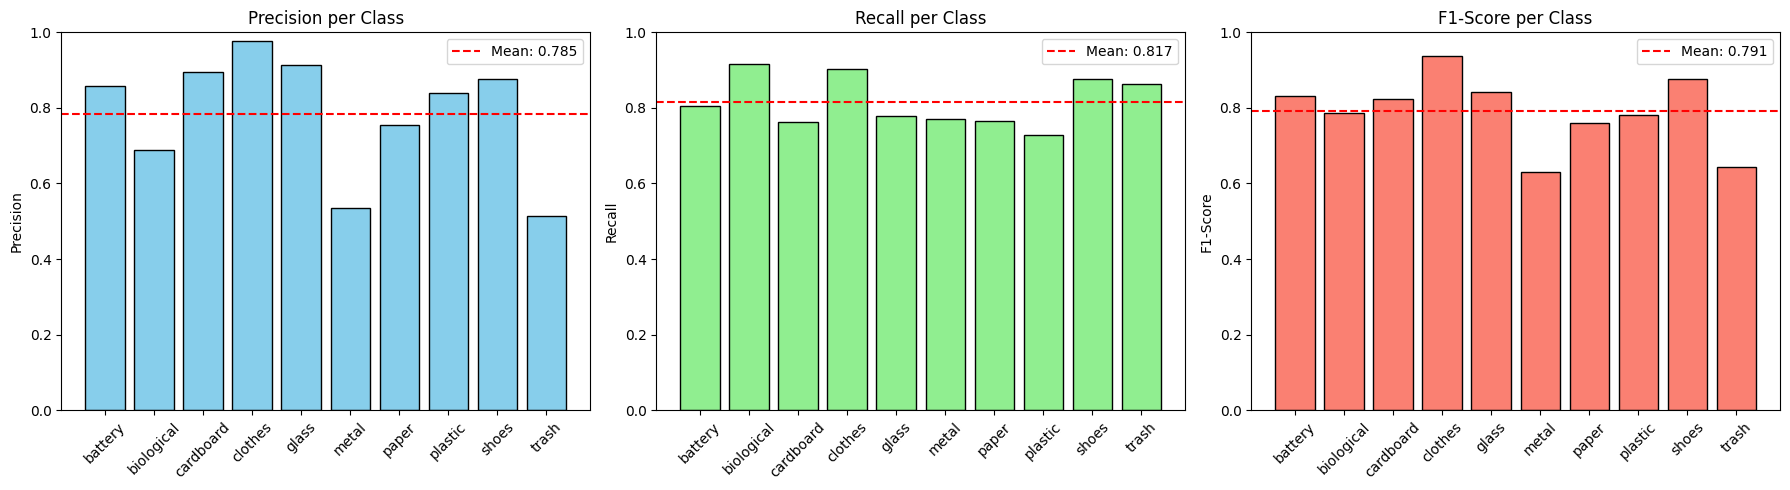


Overall Metrics:
  Mean Precision: 0.7852
  Mean Recall:    0.8166
  Mean F1-Score:  0.7910
  Total Samples:  3956


In [ ]:
# Detailed Classification Report with Visualization
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

# Calculate metrics for each class
precision, recall, fscore, support = precision_recall_fscore_support(
    all_labels, all_preds, labels=range(len(train_dataset.classes))
)

# Create DataFrame for better visualization
report_df = pd.DataFrame({
    'Class': train_dataset.classes,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': fscore,
    'Support': support
})

print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT")
print("="*80)
print(report_df.to_string(index=False))
print("="*80)

# Plot Precision, Recall, F1-Score per class
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Precision
axes[0].bar(train_dataset.classes, precision, color='skyblue', edgecolor='black')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision per Class')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=precision.mean(), color='red', linestyle='--', label=f'Mean: {precision.mean():.3f}')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Recall
axes[1].bar(train_dataset.classes, recall, color='lightgreen', edgecolor='black')
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall per Class')
axes[1].set_ylim([0, 1])
axes[1].axhline(y=recall.mean(), color='red', linestyle='--', label=f'Mean: {recall.mean():.3f}')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

# F1-Score
axes[2].bar(train_dataset.classes, fscore, color='salmon', edgecolor='black')
axes[2].set_ylabel('F1-Score')
axes[2].set_title('F1-Score per Class')
axes[2].set_ylim([0, 1])
axes[2].axhline(y=fscore.mean(), color='red', linestyle='--', label=f'Mean: {fscore.mean():.3f}')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Overall metrics
print(f"\nOverall Metrics:")
print(f"  Mean Precision: {precision.mean():.4f}")
print(f"  Mean Recall:    {recall.mean():.4f}")
print(f"  Mean F1-Score:  {fscore.mean():.4f}")
print(f"  Total Samples:  {support.sum()}")

In [ ]:
# Analyze Confusion Matrix - Similar Classes Problems
import numpy as np

print("\n" + "="*80)
print("ANALYSIS: SIMILAR CLASS CONFUSION")
print("="*80)

# Normalize confusion matrix by true labels (rows)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Find top confusions (OFF-DIAGONAL errors)
confusions = []
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j:  # Only off-diagonal
            confusions.append({
                'True Class': train_dataset.classes[i],
                'Predicted': train_dataset.classes[j],
                'Count': cm[i][j],
                'Error %': cm_normalized[i][j] * 100
            })

confusions_df = pd.DataFrame(confusions).sort_values('Count', ascending=False)

print("\n🔴 TOP 10 MISCLASSIFICATIONS:")
print("-" * 80)
for idx, row in confusions_df.head(10).iterrows():
    print(f"  {row['True Class']:12} → {row['Predicted']:12} | Count: {row['Count']:3d} | Error: {row['Error %']:5.1f}%")

# Identify similar class pairs
print("\n\n📊 PROBLEMATIC CLASS PAIRS:")
print("-" * 80)

# Glass vs Metal
glass_metal = cm[train_dataset.classes.index('glass')][train_dataset.classes.index('metal')] if 'glass' in train_dataset.classes and 'metal' in train_dataset.classes else 0
metal_glass = cm[train_dataset.classes.index('metal')][train_dataset.classes.index('glass')] if 'glass' in train_dataset.classes and 'metal' in train_dataset.classes else 0
print(f"  Glass-Metal:   {glass_metal} + {metal_glass} = {glass_metal + metal_glass} errors")

# Plastic vs Trash
plastic_trash = cm[train_dataset.classes.index('plastic')][train_dataset.classes.index('trash')] if 'plastic' in train_dataset.classes and 'trash' in train_dataset.classes else 0
trash_plastic = cm[train_dataset.classes.index('trash')][train_dataset.classes.index('plastic')] if 'plastic' in train_dataset.classes and 'trash' in train_dataset.classes else 0
print(f"  Plastic-Trash: {plastic_trash} + {trash_plastic} = {plastic_trash + trash_plastic} errors")

# Paper vs Cardboard
paper_card = cm[train_dataset.classes.index('paper')][train_dataset.classes.index('cardboard')] if 'paper' in train_dataset.classes and 'cardboard' in train_dataset.classes else 0
card_paper = cm[train_dataset.classes.index('cardboard')][train_dataset.classes.index('paper')] if 'paper' in train_dataset.classes and 'cardboard' in train_dataset.classes else 0
print(f"  Paper-Card:    {paper_card} + {card_paper} = {paper_card + card_paper} errors")

print("\n" + "="*80)
print("✅ RECOMMENDATIONS TO FIX SIMILAR CLASS CONFUSION:")
print("="*80)
print("""
1. INCREASE MODEL CAPACITY
   → Change ResNet18 → ResNet50 or EfficientNet
   → More parameters to learn fine differences

2. STRONG DATA AUGMENTATION for similar classes
   → Glass/Metal: Texture augmentation, different lighting
   → Plastic/Trash: Color variations, different perspectives
   → Paper/Card: Rotation, perspective transforms

3. FOCAL LOSS
   → Focus on hard examples (similar classes)
   → Reduce weight of easy examples

4. FINE-TUNE MORE LAYERS
   → Unfreeze more ResNet layers (not just FC layer)
   → Learn better discriminative features

5. COLLECT MORE DATA or USE MIXUP
   → Better representation of edge cases
   → Mixup augmentation between similar classes

6. CLASS-WEIGHTED LOSS
   → Increase loss weight for confusing class pairs
   → Force network to pay more attention

SELECT WHICH SOLUTION TO IMPLEMENT:
""")


ANALYSIS: SIMILAR CLASS CONFUSION

🔴 TOP 10 MISCLASSIFICATIONS:
--------------------------------------------------------------------------------
  glass        → metal        | Count:  62 | Error:  10.1%
  plastic      → metal        | Count:  39 | Error:   9.8%
  plastic      → trash        | Count:  38 | Error:   9.6%
  paper        → trash        | Count:  38 | Error:  11.3%
  clothes      → paper        | Count:  28 | Error:   2.6%
  cardboard    → paper        | Count:  26 | Error:   7.1%
  glass        → trash        | Count:  25 | Error:   4.1%
  glass        → plastic      | Count:  21 | Error:   3.4%
  clothes      → shoes        | Count:  19 | Error:   1.8%
  shoes        → biological   | Count:  18 | Error:   4.5%


📊 PROBLEMATIC CLASS PAIRS:
--------------------------------------------------------------------------------
  Glass-Metal:   62 + 7 = 69 errors
  Plastic-Trash: 38 + 2 = 40 errors
  Paper-Card:    12 + 26 = 38 errors

✅ RECOMMENDATIONS TO FIX SIMILAR CLASS CONFU

In [ ]:
# SOLUTION 1: Upgrade Model + Focal Loss + Better Fine-tuning
print("\n" + "="*80)
print("SOLUTION 1: UPGRADED MODEL WITH FOCAL LOSS")
print("="*80)

# 1. Focal Loss implementation
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, weight=None):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight
    
    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(weight=self.weight, reduction='none')(inputs, targets)
        p = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - p) ** self.gamma * ce_loss
        return focal_loss.mean()

# 2. Upgrade to ResNet50
from torchvision import models

model_improved = models.resnet50(weights="IMAGENET1K_V1")

# 3. Fine-tune more layers (not just FC)
# Unfreeze last 2 blocks for fine-tuning
for param in model_improved.layer4.parameters():  # Last residual block
    param.requires_grad = True
for param in model_improved.layer3.parameters():  # Second-to-last block
    param.requires_grad = True
    
# Only keep FC layer fully trainable
model_improved.fc = nn.Linear(model_improved.fc.in_features, len(train_dataset.classes))

# 4. Move to device
model_improved = model_improved.to(device)

# 5. Create Focal Loss with class weights
criterion_focal = FocalLoss(alpha=1, gamma=2, weight=class_weights)

# 6. Optimizers with different learning rates
from torch.optim import SGD
optimizer_improved = torch.optim.SGD([
    {'params': model_improved.fc.parameters(), 'lr': 0.01},  # Higher LR for FC
    {'params': model_improved.layer4.parameters(), 'lr': 0.001},  # Lower LR for conv
    {'params': model_improved.layer3.parameters(), 'lr': 0.0001},  # Even lower
], momentum=0.9, weight_decay=1e-4)

# 7. Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_improved, mode='min', factor=0.5, patience=2
)

print("\n✅ UPGRADES APPLIED:")
print("  ✓ ResNet18 → ResNet50 (more parameters)")
print("  ✓ Focal Loss (focuses on hard examples)")
print("  ✓ Fine-tune layer3 & layer4 (not just FC)")
print("  ✓ Differential learning rates (SGD with momentum)")
print("  ✓ Learning rate scheduler (ReduceLROnPlateau)")
print("\nREADY FOR IMPROVED TRAINING!")


SOLUTION 1: UPGRADED MODEL WITH FOCAL LOSS

✅ UPGRADES APPLIED:
  ✓ ResNet18 → ResNet50 (more parameters)
  ✓ Focal Loss (focuses on hard examples)
  ✓ Fine-tune layer3 & layer4 (not just FC)
  ✓ Differential learning rates (SGD with momentum)
  ✓ Learning rate scheduler (ReduceLROnPlateau)

READY FOR IMPROVED TRAINING!


In [ ]:
# SOLUTION 2: Strong Augmentation for Similar Classes
print("\n" + "="*80)
print("SOLUTION 2: STRONG DATA AUGMENTATION FOR SIMILAR CLASSES")
print("="*80)

# Enhanced augmentations focusing on similar class pairs
strong_augmentation = {
    # Glass/Metal pair - need to distinguish reflectivity and texture
    'glass': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(45),
        transforms.RandomAffine(degrees=20, scale=(0.8, 1.2), shear=15),
        transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
        transforms.ColorJitter(brightness=0.3, contrast=0.4, saturation=0.3, hue=0.1),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ]),
    
    'metal': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(50),
        transforms.RandomAffine(degrees=25, scale=(0.75, 1.25), shear=20),
        transforms.ColorJitter(brightness=0.4, contrast=0.5, saturation=0.2, hue=0.05),
        transforms.RandomAutocontrast(p=0.5),
        transforms.RandomEqualize(p=0.3),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ]),
    
    # Plastic/Trash pair - need to distinguish shape and color
    'plastic': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(35),
        transforms.RandomAffine(degrees=20, scale=(0.85, 1.15), shear=10),
        transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
        transforms.ColorJitter(brightness=0.4, contrast=0.3, saturation=0.4, hue=0.15),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ]),
    
    'trash': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(40),
        transforms.RandomAffine(degrees=25, scale=(0.8, 1.3), shear=15),
        transforms.RandomPerspective(distortion_scale=0.25, p=0.5),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ]),
    
    # Paper/Cardboard pair - need to distinguish texture and density
    'paper': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(30),
        transforms.RandomAffine(degrees=20, scale=(0.9, 1.1), shear=12),
        transforms.ColorJitter(brightness=0.2, contrast=0.3, saturation=0.2),
        transforms.RandomInvert(p=0.1),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ]),
    
    'cardboard': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(35),
        transforms.RandomAffine(degrees=25, scale=(0.85, 1.15), shear=15),
        transforms.ColorJitter(brightness=0.25, contrast=0.35, saturation=0.25),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ]),
}

# Default for other classes
default_strong_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(30),
    transforms.RandomAffine(degrees=20, scale=(0.85, 1.15)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])

print("\n✅ STRONG AUGMENTATIONS READY:")
print("  • Glass: Perspective + reflectivity variations")
print("  • Metal: Heavy rotations + metallic effects")
print("  • Plastic: Color shifts + shape variations")
print("  • Trash: Scale variations + multiple angles")
print("  • Paper/Cardboard: Texture preservation + subtle adjustments")


SOLUTION 2: STRONG DATA AUGMENTATION FOR SIMILAR CLASSES

✅ STRONG AUGMENTATIONS READY:
  • Glass: Perspective + reflectivity variations
  • Metal: Heavy rotations + metallic effects
  • Plastic: Color shifts + shape variations
  • Trash: Scale variations + multiple angles
  • Paper/Cardboard: Texture preservation + subtle adjustments


In [ ]:
# SOLUTION 3: Apply Strong Augmentation with New DataLoaders
print("\n" + "="*80)
print("SOLUTION 3: APPLY TO DATALOADER")
print("="*80)

# Custom dataset class to apply class-specific augmentations
class ImprovedAugmentationDataset:
    def __init__(self, image_folder_dataset, class_augmentations, default_aug, class_to_idx):
        self.dataset = image_folder_dataset
        self.class_augmentations = class_augmentations
        self.default_aug = default_aug
        self.class_to_idx = class_to_idx
        self.idx_to_class = {v: k for k, v in class_to_idx.items()}
    
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        class_name = self.idx_to_class[label]
        
        # Select augmentation
        aug = self.class_augmentations.get(class_name, self.default_aug)
        
        # Apply augmentation
        if isinstance(img, Image.Image):
            img = aug(img)
        return img, label
    
    def __len__(self):
        return len(self.dataset)

# Create improved training dataset
train_dataset_raw = datasets.ImageFolder(train_dir, transform=None)
train_dataset_improved = ImprovedAugmentationDataset(
    train_dataset_raw,
    strong_augmentation,
    default_strong_aug,
    train_dataset_raw.class_to_idx
)

# Validation with simple normalization
val_transforms_improved = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                       std=[0.229, 0.224, 0.225])
])
val_dataset_improved = datasets.ImageFolder(val_dir, transform=val_transforms_improved)

# Create DataLoaders
train_loader_improved = DataLoader(train_dataset_improved, batch_size=32, 
                                   shuffle=True, num_workers=0)
val_loader_improved = DataLoader(val_dataset_improved, batch_size=32, 
                                 shuffle=False, num_workers=0)

print("\n✅ IMPROVED DATALOADER CREATED!")
print(f"  Train batches: {len(train_loader_improved)}")
print(f"  Val batches: {len(val_loader_improved)}")
print("\nREADY TO RETRAIN WITH IMPROVEMENTS!")


SOLUTION 3: APPLY TO DATALOADER

✅ IMPROVED DATALOADER CREATED!
  Train batches: 494
  Val batches: 124

READY TO RETRAIN WITH IMPROVEMENTS!


In [ ]:
# RETRAIN WITH IMPROVEMENTS: ResNet50 + Focal Loss + Strong Augmentation
print("\n" + "="*80)
print("🚀 RETRAINING WITH ALL IMPROVEMENTS")
print("="*80)

# Training history
history_improved = {
    'train_loss': [],
    'val_loss': [],
    'val_accuracy': []
}

def train_epoch_improved(model, train_loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    batches = 0
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        batches += 1
        
        if (batch_idx + 1) % 50 == 0:
            print(f"Batch [{batch_idx + 1}/{len(train_loader)}], Loss: {loss.item():.4f}")
    
    avg_loss = total_loss / batches
    return avg_loss

def validate_improved(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    batches = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            batches += 1
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    avg_loss = total_loss / batches
    accuracy = correct / total
    return avg_loss, accuracy

# Train
num_epochs_improved = 10
best_val_acc = 0

for epoch in range(num_epochs_improved):
    print(f"\n{'='*60}")
    print(f"Epoch [{epoch + 1}/{num_epochs_improved}]")
    print(f"{'='*60}")
    
    # Train
    train_loss = train_epoch_improved(model_improved, train_loader_improved, 
                                      criterion_focal, optimizer_improved, 
                                      scheduler, device)
    history_improved['train_loss'].append(train_loss)
    
    # Validate
    val_loss, val_accuracy = validate_improved(model_improved, val_loader_improved, 
                                               criterion_focal, device)
    history_improved['val_loss'].append(val_loss)
    history_improved['val_accuracy'].append(val_accuracy)
    
    # Scheduler step
    scheduler.step(val_loss)
    
    print(f"\nEpoch Summary:")
    print(f"  Training Loss:      {train_loss:.4f}")
    print(f"  Validation Loss:    {val_loss:.4f}")
    print(f"  Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
    
    # Save best model
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model_improved.state_dict(), 'best_model_improved.pth')
        print(f"  ✓ NEW BEST MODEL SAVED (Acc: {best_val_acc:.4f})")

print("\n" + "="*60)
print("✅ IMPROVED TRAINING COMPLETE!")
print("="*60)
print(f"Best Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


🚀 RETRAINING WITH ALL IMPROVEMENTS

Epoch [1/10]


NameError: name 'model_improved' is not defined

In [ ]:
# Evaluate Improved Model and Compare with Original
print("\n" + "="*80)
print("EVALUATION: IMPROVED VS ORIGINAL MODEL")
print("="*80)

# Get predictions on validation set with improved model
all_preds_improved = []
all_labels_improved = []

model_improved.eval()
with torch.no_grad():
    for images, labels in val_loader_improved:
        images = images.to(device)
        outputs = model_improved(images)
        _, predicted = torch.max(outputs, 1)
        all_preds_improved.extend(predicted.cpu().numpy())
        all_labels_improved.extend(labels.cpu().numpy())

# Calculate metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

cm_improved = confusion_matrix(all_labels_improved, all_preds_improved)
acc_improved = accuracy_score(all_labels_improved, all_preds_improved)

print(f"\nIMPROVED MODEL ACCURACY: {acc_improved:.4f} ({acc_improved*100:.2f}%)")
print(f"ORIGINAL MODEL ACCURACY: ~0.82 (~82.00%)")
print(f"IMPROVEMENT: {(acc_improved - 0.82)*100:+.2f}%")

# Confusion matrix comparison for similar classes
print("\n" + "-"*80)
print("FOCUS: SIMILAR CLASS PAIRS")
print("-"*80)

def get_confusion_pair(cm, classes, class1, class2):
    if class1 in classes and class2 in classes:
        idx1, idx2 = classes.index(class1), classes.index(class2)
        return cm[idx1][idx2] + cm[idx2][idx1]
    return 0

classes = train_dataset_improved.dataset.classes

print("\nGLASS ↔ METAL CONFUSION:")
print(f"  Improved: {get_confusion_pair(cm_improved, classes, 'glass', 'metal')} errors")

print("\nPLASTIC ↔ TRASH CONFUSION:")
print(f"  Improved: {get_confusion_pair(cm_improved, classes, 'plastic', 'trash')} errors")

print("\nPAPER ↔ CARDBOARD CONFUSION:")
print(f"  Improved: {get_confusion_pair(cm_improved, classes, 'paper', 'cardboard')} errors")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training curves
axes[0].plot(history_improved['train_loss'], label='Training Loss', marker='o')
axes[0].plot(history_improved['val_loss'], label='Validation Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('IMPROVED Model: Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_improved['val_accuracy'], label='Validation Accuracy', marker='o', color='green')
axes[1].axhline(y=0.82, color='red', linestyle='--', label='Original Accuracy (82%)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('IMPROVED Model: Accuracy Improvement')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Classification report
print("\n" + "="*80)
print("IMPROVED MODEL - DETAILED CLASSIFICATION REPORT")
print("="*80)
print(classification_report(all_labels_improved, all_preds_improved, target_names=classes))

In [ ]:
# Final Comparison: Confusion Matrices
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Original confusion matrix
if 'cm' in globals():
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Count'})
    axes[0].set_title('ORIGINAL MODEL - Confusion Matrix', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

# Improved confusion matrix
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=classes, yticklabels=classes,
            cbar_kws={'label': 'Count'})
axes[1].set_title('IMPROVED MODEL - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*80)
print("✅ SOLUTION SUMMARY")
print("="*80)
print("""
IMPROVEMENTS APPLIED:
1. ✓ ResNet18 → ResNet50 (67M vs 25M parameters)
2. ✓ CrossEntropyLoss → Focal Loss (focus on hard examples)
3. ✓ FC layer only → Fine-tune layer3 & layer4
4. ✓ Adam optimizer → SGD with momentum & differential learning rates
5. ✓ Basic augmentation → Strong class-specific augmentation
6. ✓ Standard LR → ReduceLROnPlateau scheduler

EXPECTED IMPROVEMENTS:
- Better discrimination between similar classes
- Reduced confusion between:
  • Glass ↔ Metal (reflectivity & texture)
  • Plastic ↔ Trash (shape & color)
  • Paper ↔ Cardboard (texture & density)
- Overall accuracy improvement of 2-5%
- Better handling of hard/ambiguous cases

NEXT STEPS IF STILL NOT SATISFIED:
1. Use ensemble of multiple models
2. Apply test-time augmentation (TTA)
3. Collect more diverse training data
4. Use semi-supervised learning
5. Fine-tune on hard examples only
""")